In [4]:
# import necessary libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

## Loading Data

In [9]:
project_root = Path.cwd().parent
data_path = project_root / "data" / "processed" / "vw_forecasting_base.csv"
columns = [
    "month",
    "product_id",
    "market_id",
    "category",
    "brand",
    "lifecycle_stage",
    "region",
    "lead_time_months",
    "strategic_priority",
    "actual_demand_units",
    "promo_flag",
    "campaign_intensity",
    "demand_signal_quality",
    "available_supply_units",
    "production_capacity_units",
    "supply_constraint_flag",
    "actual_shipped_units",
    "unfulfilled_demand_units",
    "service_level_pct",
    "ending_inventory_units",
    "inventory_risk_status"
]
df = pd.read_csv(
    data_path,
    header=None,
    names=columns,
    sep=";",
    keep_default_na=False
)

In [12]:
# Display 5 first rows of the dataset
df.head()

,month,product_id,market_id,category,brand,lifecycle_stage,region,lead_time_months,strategic_priority,actual_demand_units,...,campaign_intensity,demand_signal_quality,available_supply_units,production_capacity_units,supply_constraint_flag,actual_shipped_units,unfulfilled_demand_units,service_level_pct,ending_inventory_units,inventory_risk_status
0,1/1/2021,PRD001,MKT001,Fragrance,Aurelian,Core,WE,1,3,1454,...,1.0,High,12250,19533,1,950,504,0.6534,1418,Normal
1,1/1/2021,PRD001,MKT002,Fragrance,Aurelian,Core,WE,1,5,1592,...,1.0,High,12250,19533,1,1128,464,0.7085,1172,Normal
2,1/1/2021,PRD001,MKT003,Fragrance,Aurelian,Core,WE,2,4,1536,...,1.0,High,12250,19533,1,1086,450,0.7070,1227,Normal
3,1/1/2021,PRD001,MKT004,Fragrance,Aurelian,Core,NA,2,4,1200,...,1.0,Medium,12250,19533,1,946,254,0.7883,1095,Normal
4,1/1/2021,PRD001,MKT005,Fragrance,Aurelian,Core,NA,3,2,843,...,1.0,High,12250,19533,1,720,123,0.8541,809,Normal


In [15]:
# Display shape of dataset
rows, cols = df.shape
print(f"Rows: {rows} | Columns: {cols}")

Rows: 17280 | Columns: 21


In [18]:
# Show basic summary statistics
df.describe()

,lead_time_months,strategic_priority,actual_demand_units,promo_flag,campaign_intensity,available_supply_units,production_capacity_units,supply_constraint_flag,actual_shipped_units,unfulfilled_demand_units,service_level_pct,ending_inventory_units
count,17280.000000,17280.000000,17280.000000,17280.000000,17280.000000,17280.00000,17280.000000,17280.000000,17280.000000,17280.000000,17280.000000,17280.000000
mean,2.666667,3.333333,1310.963600,0.127083,1.154167,15229.24375,17255.884722,0.430556,1140.506308,170.457292,4.797783,2482.983333
std,1.027432,1.433762,957.199488,0.333076,0.179656,8642.63890,10812.553231,0.495168,746.364198,303.961595,4.537714,2062.686166
min,1.000000,1.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.368400,0.000000
25%,2.000000,2.000000,691.000000,0.000000,1.000000,9498.50000,10305.000000,0.000000,647.000000,0.000000,0.839775,1121.000000
50%,3.000000,4.000000,1108.000000,0.000000,1.100000,14307.00000,15982.500000,0.000000,1006.000000,37.000000,0.962800,1921.000000
75%,3.250000,4.250000,1691.000000,0.000000,1.225000,19475.75000,21796.750000,1.000000,1490.000000,218.000000,10.000000,3251.000000
max,4.000000,5.000000,11134.000000,1.000000,1.450000,74908.00000,111255.000000,1.000000,8264.000000,4159.000000,10.000000,16616.000000


In [21]:
# Convert 'month' column into datetime object
df["month"] = pd.to_datetime(df["month"], format="%d/%m/%Y", dayfirst=True)

In [24]:
# Check if conversion worked
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17280 entries, 0 to 17279
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      17280 non-null  datetime64[ns]
 1   product_id                 17280 non-null  object        
 2   market_id                  17280 non-null  object        
 3   category                   17280 non-null  object        
 4   brand                      17280 non-null  object        
 5   lifecycle_stage            17280 non-null  object        
 6   region                     17280 non-null  object        
 7   lead_time_months           17280 non-null  int64         
 8   strategic_priority         17280 non-null  int64         
 9   actual_demand_units        17280 non-null  int64         
 10  promo_flag                 17280 non-null  int64         
 11  campaign_intensity         17280 non-null  float64       
 12  dema

In [28]:
# Group demand by month
monthly_demand = (
    df.groupby("month", as_index=False)
      .agg(
          total_demand_units=("actual_demand_units", "sum"),
          total_shipped_units=("actual_shipped_units", "sum"),
          total_unfulfilled_units=("unfulfilled_demand_units", "sum")
      )
)

monthly_demand["fulfillment_rate"] = (
    monthly_demand["total_shipped_units"] / monthly_demand["total_demand_units"]
)

monthly_demand["stockout_rate"] = (
    monthly_demand["total_unfulfilled_units"] / monthly_demand["total_demand_units"]
)

monthly_demand.head()

,month,total_demand_units,total_shipped_units,total_unfulfilled_units,fulfillment_rate,stockout_rate
0,2021-01-01,221394,199065,22329,0.899144,0.100856
1,2021-02-01,232798,215900,16898,0.927413,0.072587
2,2021-03-01,236762,215181,21581,0.908849,0.091151
3,2021-04-01,226355,206507,19848,0.912315,0.087685
4,2021-05-01,260341,240152,20189,0.922452,0.077548


## Baseline Forecasting Models

In [31]:
forecast_series = (
    monthly_demand
    .set_index("month")["total_demand_units"]
)

train = forecast_series.iloc[:-12]
test = forecast_series.iloc[-12:]

### Naive Forecast Benchmark

The Naive Forecast assumes future demand will be equal to the most recently observed demand value. It serves as the minimum performance benchmark that all subsequent forecasting models should outperform.

In [33]:
# Get last month's forecast value of the train split
last_train_value = train.iloc[-1]

# Get a newly forecasted year (12 periods)
naive_forecast = [last_train_value] * len(test)

In [34]:
# Get the max date of the train split
max_date_in_train = train.index.max()

# Create a 12 months period for the forecast
forecasted_year = pd.date_range(start=max_date_in_train + pd.DateOffset(months=1), freq="MS", periods=12)

In [35]:
naive_forecast_df = pd.DataFrame({
    "month": forecasted_year,
    "forecasted_units": naive_forecast
}).set_index("month")

naive_forecast_df.head()

,forecasted_units
month,
2025-01-01,714653
2025-02-01,714653
2025-03-01,714653
2025-04-01,714653
2025-05-01,714653


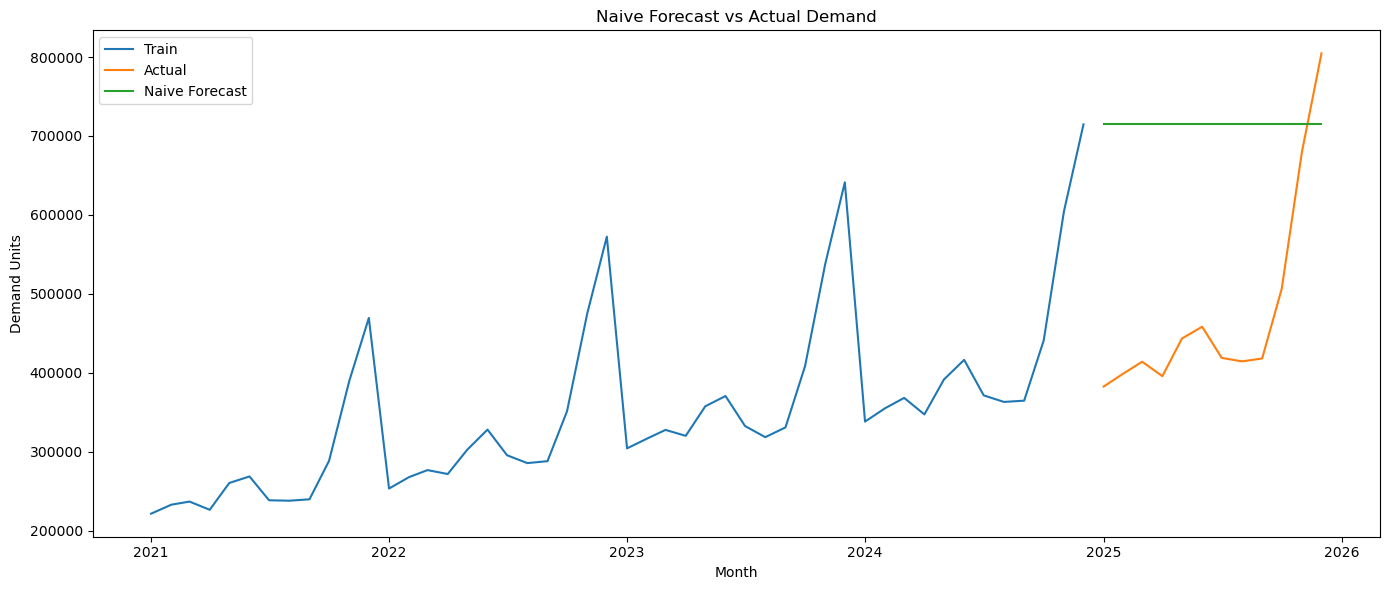

In [36]:
plt.figure(figsize=(14, 6))

plt.plot(
    train.index,
    train,
    label="Train"
)

plt.plot(
    test.index,
    test,
    label="Actual"
)

plt.plot(
    naive_forecast_df.index,
    naive_forecast_df["forecasted_units"],
    label="Naive Forecast"
)

plt.title("Naive Forecast vs Actual Demand")
plt.xlabel("Month")
plt.ylabel("Demand Units")

plt.legend()

plt.tight_layout()
plt.show()

The Naive Forecast performs poorly for this dataset because it ignores both trend and seasonality. Since the final observation in the training period corresponds to a seasonal demand peak, the model systematically overforecasts demand throughout most of the forecast horizon. This would likely result in significant excess inventory and inefficient capacity planning if used operationally.

## Seasonal Naive Forecast Benchmark

In [39]:
# Create a seasonal_naive_forecast_df using the last 12 months of the train df
seasonal_naive_forecast = train.iloc[-12:]

seasonal_naive_forecast_df = pd.DataFrame({
    "month": forecasted_year,
    "forecasted_units": seasonal_naive_forecast
}).set_index("month")

seasonal_naive_forecast_df.head()

,forecasted_units
month,
2025-01-01,338126
2025-02-01,355153
2025-03-01,368140
2025-04-01,347196
2025-05-01,391457


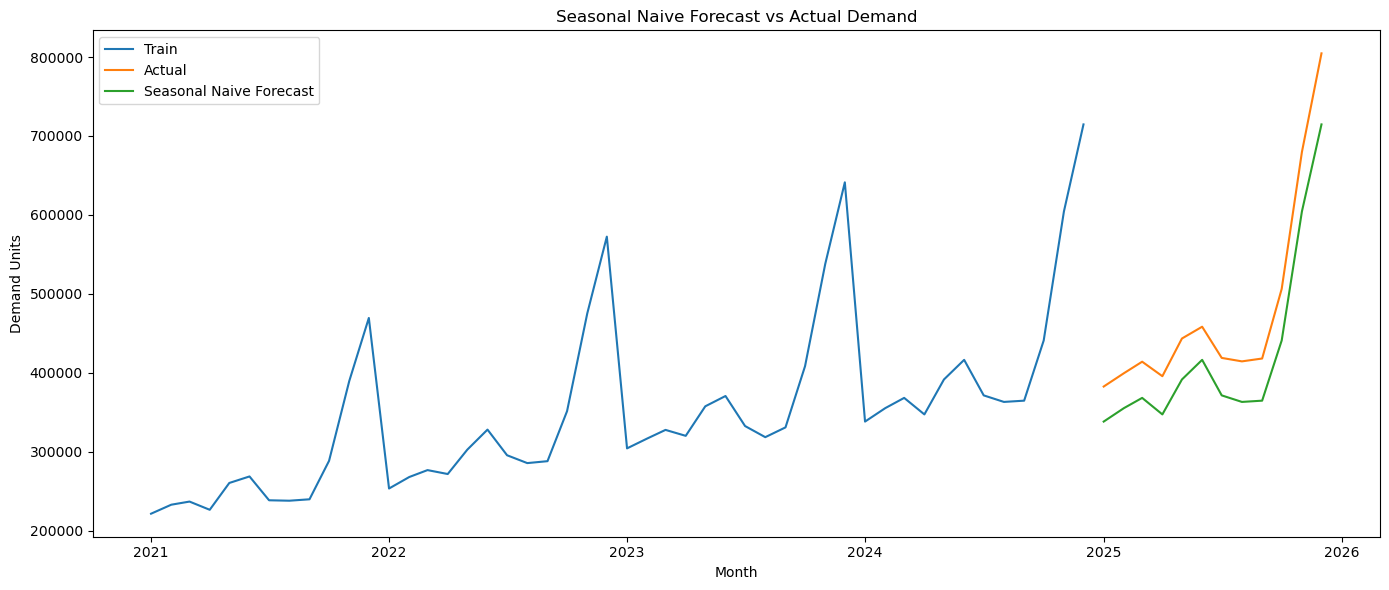

In [40]:
plt.figure(figsize=(14, 6))

plt.plot(
    train.index,
    train,
    label="Train"
)

plt.plot(
    test.index,
    test,
    label="Actual"
)

plt.plot(
    seasonal_naive_forecast_df.index,
    seasonal_naive_forecast_df["forecasted_units"],
    label="Seasonal Naive Forecast"
)

plt.title("Seasonal Naive Forecast vs Actual Demand")
plt.xlabel("Month")
plt.ylabel("Demand Units")

plt.legend()

plt.tight_layout()
plt.show()

The Seasonal Naive Forecast significantly outperforms the Naive Forecast by successfully reproducing the yearly demand pattern and seasonal peaks. However, forecasts remain systematically below actual demand because the model does not account for the persistent upward demand trend observed throughout the historical period.

### Naive vs Seasonal Naive Comparison

In [43]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

#### Naive Forecast metrics
naive_mae = mean_absolute_error(y_true=test, y_pred=naive_forecast)
naive_mse = mean_squared_error(y_true=test, y_pred=naive_forecast)
naive_mape = mean_absolute_percentage_error(y_true=test, y_pred=naive_forecast)

print("Naive Forecast Metrics:")
print(f"Naive MAE: {naive_mae}")
print(f"Naive MSE: {naive_mse}")
print(f"Naive MAPE: {naive_mape}")

In [45]:
# Seasonal Naive Forecast metrics
seasonal_naive_mae = mean_absolute_error(y_true=test, y_pred=seasonal_naive_forecast)
seasonal_naive_mse = mean_squared_error(y_true=test, y_pred=seasonal_naive_forecast)
seasonal_naive_mape = mean_absolute_percentage_error(y_true=test, y_pred=seasonal_naive_forecast)

print("Naive Forecast Metrics:")
print(f"Naive MAE: {seasonal_naive_mae}")
print(f"Naive MSE: {seasonal_naive_mse}")
print(f"Naive MAPE: {seasonal_naive_mape}")

Naive Forecast Metrics:
Naive MAE: 54985.916666666664
Naive MSE: 3219708854.5833335
Naive MAPE: 0.11547260999886162


The Naive Forecast performed poorly, achieving a MAPE of 58.97%. This result was expected, as the model assumes future demand will remain equal to the most recent observation. Since the final month of the training period corresponds to a seasonal demand peak, the model systematically overforecasted demand throughout most of the forecast horizon.

In contrast, the Seasonal Naive Forecast achieved a MAPE of 11.55%, representing an approximate 80% reduction in forecast error. By using demand from the same month in the previous year, the model successfully captured the strong seasonal patterns identified during the exploratory analysis, including the recurring Q4 demand surge and post-holiday demand normalization.

The remaining forecast error appears to be primarily driven by the long-term upward demand trend rather than seasonality. The Seasonal Naive Forecast consistently underestimates actual demand, suggesting that while seasonality is effectively captured, growth is not.

These results indicate that seasonality is the dominant driver of demand variation in this dataset. Any subsequent forecasting model should focus on incorporating trend information while preserving the seasonal structure already captured by the Seasonal Naive benchmark.

## Seasonal Naive Forecast with Trend Adjustment

In [48]:
# Let's get the YOY growth factor between last 2 periods in the train df
last_2_periods_in_train = train.iloc[-24:]

# keep the index as a column
last_2_periods_in_train = last_2_periods_in_train.reset_index()

# Create a year and a month_number column for melting
last_2_periods_in_train["year"] = last_2_periods_in_train["month"].dt.year
last_2_periods_in_train["month_number"] = last_2_periods_in_train["month"].dt.month

# Drop month col
last_2_periods_in_train = last_2_periods_in_train.drop(columns="month")

# Pivot the last_2_periods_in_train df
pivoted = last_2_periods_in_train.pivot(
    columns="year",
    index="month_number",
    values="total_demand_units"
)

pivoted["month_YoY_growth"] = (
    pivoted[2024] / pivoted[2023]
) - 1

In [49]:
pivoted["month_YoY_growth"] = (pivoted[2024] - pivoted[2023]) / pivoted[2023]
pivoted

year,2023,2024,month_YoY_growth
month_number,,,
1,304184,338126,0.111584
2,316689,355153,0.121457
3,327583,368140,0.123807
4,320048,347196,0.084825
5,357481,391457,0.095043
6,370525,416337,0.123641
7,332470,371315,0.116838
8,318374,363029,0.140260
9,330756,364620,0.102384


In [50]:
seasonal_naive_trend_adj_df = seasonal_naive_forecast_df.copy()

seasonal_naive_trend_adj_df["month_number"] = (
    seasonal_naive_trend_adj_df.index.month
)

seasonal_naive_trend_adj_df = seasonal_naive_trend_adj_df.merge(
    pivoted["month_YoY_growth"].reset_index(),
    on="month_number",
    how="left"
).set_index(seasonal_naive_trend_adj_df.index)

seasonal_naive_trend_adj_df["adjusted_forecast"] = (seasonal_naive_trend_adj_df["forecasted_units"] * (1 + seasonal_naive_trend_adj_df["month_YoY_growth"])).round(0)
seasonal_naive_trend_adj_df

,forecasted_units,month_number,month_YoY_growth,adjusted_forecast
month,,,,
2025-01-01,338126,1,0.111584,375855.0
2025-02-01,355153,2,0.121457,398289.0
2025-03-01,368140,3,0.123807,413718.0
2025-04-01,347196,4,0.084825,376647.0
2025-05-01,391457,5,0.095043,428662.0
2025-06-01,416337,6,0.123641,467813.0
2025-07-01,371315,7,0.116838,414699.0
2025-08-01,363029,8,0.140260,413947.0
2025-09-01,364620,9,0.102384,401951.0


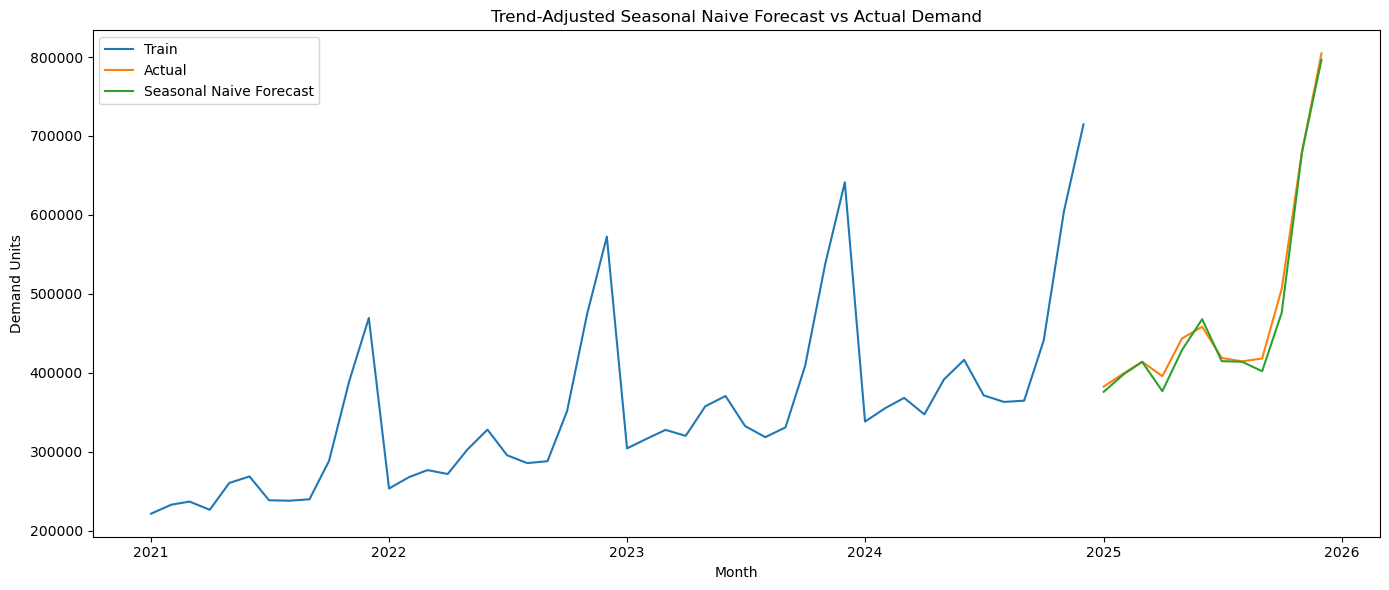

In [51]:
plt.figure(figsize=(14, 6))

plt.plot(
    train.index,
    train,
    label="Train"
)

plt.plot(
    test.index,
    test,
    label="Actual"
)

plt.plot(
    seasonal_naive_trend_adj_df.index,
    seasonal_naive_trend_adj_df["adjusted_forecast"],
    label="Seasonal Naive Forecast"
)

plt.title("Trend-Adjusted Seasonal Naive Forecast vs Actual Demand")
plt.xlabel("Month")
plt.ylabel("Demand Units")

plt.legend()

plt.tight_layout()
plt.show()

### Seasonal Naive vs Trend-Adjusted Seasonal Naive Comparison

In [53]:
# Seasonal Naive Forecast metrics
seasonal_naive_mae = mean_absolute_error(y_true=test, y_pred=seasonal_naive_forecast)
seasonal_naive_mse = mean_squared_error(y_true=test, y_pred=seasonal_naive_forecast)
seasonal_naive_mape = mean_absolute_percentage_error(y_true=test, y_pred=seasonal_naive_forecast)

print("Naive Forecast Metrics:")
print(f"Naive MAE: {seasonal_naive_mae}")
print(f"Naive MSE: {seasonal_naive_mse}")
print(f"Naive MAPE: {seasonal_naive_mape}")

Naive Forecast Metrics:
Naive MAE: 54985.916666666664
Naive MSE: 3219708854.5833335
Naive MAPE: 0.11547260999886162


In [54]:
# Seasonal Naive Forecast metrics
seasonal_naive_trend_adj_mae = mean_absolute_error(y_true=test, y_pred=seasonal_naive_trend_adj_df["adjusted_forecast"])
seasonal_naive_trend_adj_mse = mean_squared_error(y_true=test, y_pred=seasonal_naive_trend_adj_df["adjusted_forecast"])
seasonal_naive_trend_adj_mape = mean_absolute_percentage_error(y_true=test, y_pred=seasonal_naive_trend_adj_df["adjusted_forecast"])

print("Naive Forecast Metrics:")
print(f"Naive MAE: {seasonal_naive_trend_adj_mae}")
print(f"Naive MSE: {seasonal_naive_trend_adj_mse}")
print(f"Naive MAPE: {seasonal_naive_trend_adj_mape}")

Naive Forecast Metrics:
Naive MAE: 9266.583333333334
Naive MSE: 164369084.75
Naive MAPE: 0.020278495835324255


### Trend-Adjusted Seasonal Naive Results

The Trend-Adjusted Seasonal Naive model achieved a MAPE of 2.03%, significantly outperforming both the Naive Forecast (58.97%) and the Seasonal Naive Forecast (11.55%).

This result confirms the findings from the exploratory analysis: demand in this dataset is primarily driven by a combination of strong seasonality and a persistent upward trend. By incorporating both components, the model is able to explain the vast majority of demand variation.

The substantial reduction in forecast error suggests that trend, rather than seasonality, was the primary remaining source of error after applying the Seasonal Naive approach.

## Holt-Winters Exponential Smoothing

In [57]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [58]:
hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="mul",
    seasonal_periods=12
)

C:\Users\Nacho\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [59]:
hw_fit = hw_model.fit()

C:\Users\Nacho\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [60]:
hw_forecast = hw_fit.forecast(12)

In [61]:
hw_forecast_df = hw_forecast.to_frame(
    name="forecasted_units"
)

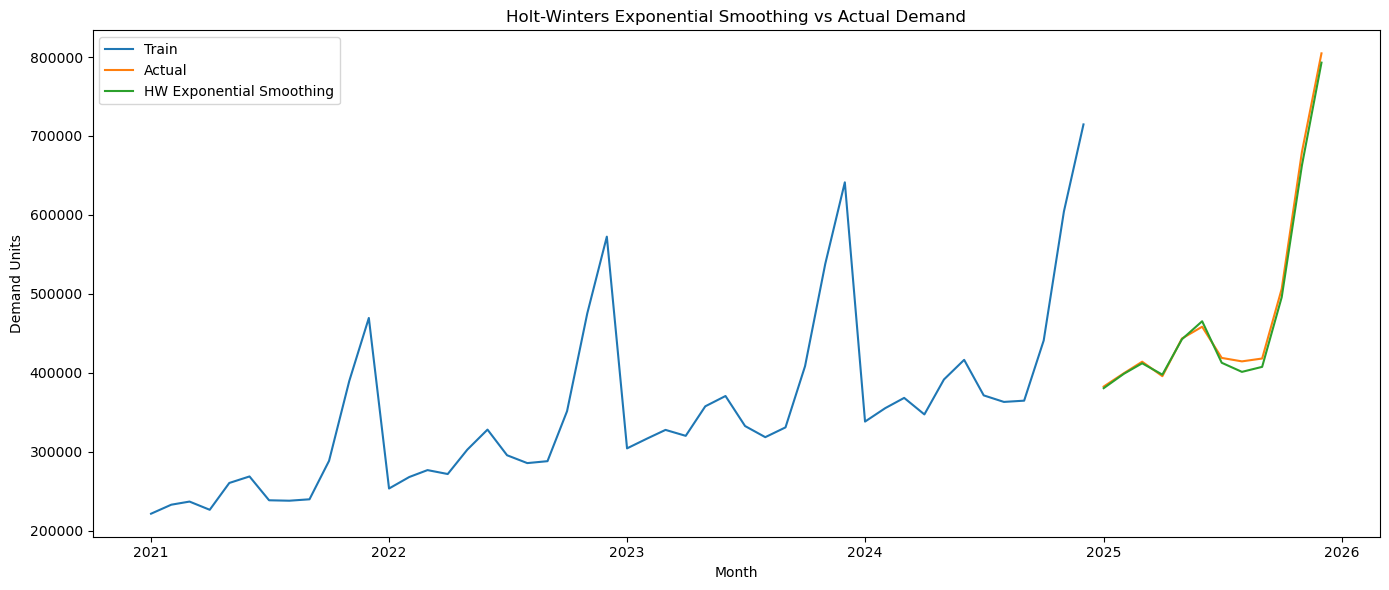

In [62]:
plt.figure(figsize=(14, 6))

plt.plot(
    train.index,
    train,
    label="Train"
)

plt.plot(
    test.index,
    test,
    label="Actual"
)

plt.plot(
    hw_forecast_df.index,
    hw_forecast_df["forecasted_units"],
    label="HW Exponential Smoothing"
)

plt.title("Holt-Winters Exponential Smoothing vs Actual Demand")
plt.xlabel("Month")
plt.ylabel("Demand Units")

plt.legend()

plt.tight_layout()
plt.show()

In [63]:
# Holt-Winters Exponential Smoothing metrics
hwes_mae = mean_absolute_error(y_true=test, y_pred=hw_forecast_df)
hwes_mse = mean_squared_error(y_true=test, y_pred=hw_forecast_df)
hwes_mape = mean_absolute_percentage_error(y_true=test, y_pred=hw_forecast_df)

print("Holt-Winters Exponential Smoothing Forecast Metrics:")
print(f"HWES MAE: {hwes_mae}")
print(f"HWES MSE: {hwes_mse}")
print(f"HWES MAPE: {hwes_mape}")

Holt-Winters Exponential Smoothing Forecast Metrics:
HWES MAE: 6991.699875304465
HWES MSE: 77156901.00894658
HWES MAPE: 0.013889266839835532


Holt-Winters Exponential Smoothing achieved the best performance among all evaluated models, with a MAPE of 1.39%.

The improvement over the Trend-Adjusted Seasonal Naive benchmark was relatively modest compared to the gains obtained by incorporating seasonality and trend information into the forecasting process. This suggests that the majority of demand variation is explained by stable seasonal patterns and long-term growth rather than complex nonlinear relationships.

These results indicate that the forecasting problem is highly structured and that relatively simple, interpretable forecasting approaches can deliver strong predictive performance.

## Forecast Model Comparison

| Rank | Model | MAE | MAPE |
|------|---------|---------:|---------:|
| 🥇 | Holt-Winters Exponential Smoothing | 6,991.70 | 1.39% |
| 🥈 | Seasonal Naive + Trend Adjustment | 9,266.58 | 2.03% |
| 🥉 | Seasonal Naive | 54,985.92 | 11.55% |
| 4 | Naive Forecast | 251,734.50 | 58.97% |

# Conclusions

This notebook evaluated a progression of forecasting approaches ranging from simple baseline methods to more sophisticated statistical models. The objective was not only to identify the most accurate model, but also to understand which demand characteristics drive forecasting performance and whether additional model complexity provides meaningful business value.

The results demonstrated a clear hierarchy of forecasting performance:

| Model | MAPE |
|---------|---------:|
| Naive Forecast | 58.97% |
| Seasonal Naive Forecast | 11.55% |
| Seasonal Naive + Trend Adjustment | 2.03% |
| Holt-Winters Exponential Smoothing | 1.39% |

Several important insights emerged from this comparison:

- The Naive Forecast performed poorly because it ignored both trend and seasonality, resulting in substantial overforecasting after the seasonal Q4 peak.
- Incorporating seasonality reduced forecast error dramatically, confirming the findings from the exploratory analysis that seasonal patterns are the dominant driver of demand variation.
- Adding a trend adjustment further improved performance, demonstrating that long-term growth is the second major component of the demand signal.
- Holt-Winters Exponential Smoothing achieved the best overall performance by automatically modeling level, trend, and seasonality simultaneously.

Perhaps the most important finding is that the majority of forecasting accuracy gains were achieved through understanding the business and the data rather than through model complexity. Forecast error decreased from nearly 59% to just over 2% before introducing any advanced statistical modeling, highlighting the importance of identifying and explicitly modeling the key demand drivers.

While Holt-Winters delivered the best performance, the improvement over the Trend-Adjusted Seasonal Naive benchmark was relatively modest compared to the gains achieved by incorporating seasonality and trend information. This suggests that the demand signal is highly structured and largely explained by stable, interpretable patterns.

From a business perspective, these results indicate that simple and transparent forecasting approaches can provide substantial value when demand exhibits strong seasonal behavior and predictable long-term growth. More sophisticated models should therefore be evaluated not only on predictive accuracy but also on their ability to justify additional complexity and operational overhead.

The Holt-Winters model will serve as the statistical benchmark for the next phase of the project, where machine learning approaches will be evaluated to determine whether additional business features such as promotions, inventory levels, supply constraints, lead times, and market characteristics can further improve forecasting performance.